# Task epsilon — the inventory model with stochastic demand

This is the graded homework of Tuesday 15 September, due at the start of the Thursday
class, where one of you presents it.

Demand in the class model was a fixed number. Make it random, exactly as set up at the
end of the *Dynamic programming* chapter <https://dse.iskh.me/dp>: the value function
lives on the grid of $(x,d)$, the continuation value is averaged over next period
demand, and the horizon is still finite, so backwards induction still solves it.

$$V_t(x,d) = \max_{q \ge 0} \Big\{ p \min\{x,d\} - r \big[ \max\{x-d,0\} + q \big] - c \mathbb{1}\{q>0\} + \beta \sum_{d'} V_{t+1}\big( \max\{x-d,0\} + q, d' \big) pr(d') \Big\}$$

$$V_T(x,d) = p \min\{x,d\} - r \max\{x-d,0\}$$

- Work in your copy of this notebook, in `solutions/epsilon_inventory/`
- Add cells as needed
- Restart the kernel and run all before committing, so the outputs match the code
- Submit as described in the lecture notes <https://dse.iskh.me/workflow/#submission>

## The model from the class

Provided — the deterministic model of Tuesday. Extend it, do not retype it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]

class inventory_model:
    '''Small class to hold model fundamentals and its solution'''

    def __init__(self,label='noname',
                 max_inventory=10,  # upper bound on the state space
                 c = 3.2,           # fixed cost of order
                 p = 2.5,           # profit per unit of good
                 r = 0.5,           # storage cost per unit of good
                 β = 0.95,          # discount factor
                 demand = 4         # fixed demand
                 ):
        '''Create model with default parameters'''
        self.label=label # label for the model instance
        self.c, self.p, self.r, self.β = c, p, r, β
        self.demand = demand
        self.n = max_inventory+1    # number of inventory levels
        self.upper = max_inventory  # upper boundary on inventory
        self.x = np.arange(self.n)  # all possible values of inventory (state space)

    def __repr__(self):
        '''String representation of the model'''
        return 'Inventory model labeled "{}"\nParamters (c,p,r,β) = ({},{},{},{})\nDemand={}\nUpper bound on inventory {}' \
               .format (self.label,self.c,self.p,self.r,self.β,self.demand,self.upper)

    def sales(self,x,d):
        '''Sales in given period'''
        return np.minimum(x,d)

    def next_x(self,x,d,q):
        '''Inventory to be stored, becomes next period state'''
        return x - self.sales(x,d) + q

    def profit(self,x,d,q):
        '''Profit in given period'''
        return self.p * self.sales(x,d) - self.r * self.next_x(x,d,q) - self.c * (q>0)

## 1. Random demand

Add a parameter $\lambda \in (0,1)$ and a method `demand_pr()` returning the vector of
probabilities of $d = 0,1,\dots,N$ under the **truncated geometric** distribution,
$pr_i = (1-\lambda)^i \lambda$, with the last probability corrected so that the vector
sums to one.

Add a `plot=True` switch that draws the distribution, and check that the probabilities
sum to one for several $\lambda$. What is the mean demand at your $\lambda$, and does
the truncation matter at that value?

Inventory model labeled "test"
Parameters (c,p,r,β) = (3.2,2.5,0.5,0.95)
Demand ~ truncated geometric with λ=0.25
Upper bound on inventory 25


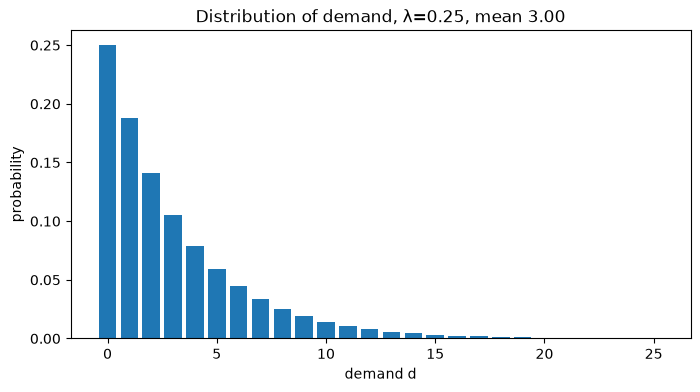

     λ        sum       mean      (1-λ)/λ    mass at N
  0.05   1.000000     13.730       19.000     2.77e-01
  0.10   1.000000      8.354        9.000     7.18e-02
  0.25   1.000000      2.998        3.000     7.53e-04
  0.50   1.000000      1.000        1.000     2.98e-08
  0.90   1.000000      0.111        0.111     0.00e+00


In [2]:
class inventory_model_stochastic(inventory_model):
    '''Inventory model with truncated geometric demand on the inventory grid'''

    def __init__(self, λ=0.25, **kwargs):
        '''λ is the parameter of the geometric distribution, everything else as before'''
        super().__init__(**kwargs)
        self.λ = λ

    def __repr__(self):
        '''String representation of the model'''
        return ('Inventory model labeled "{}"\nParameters (c,p,r,β) = ({},{},{},{})\n'
                'Demand ~ truncated geometric with λ={}\nUpper bound on inventory {}'
                ).format(self.label,self.c,self.p,self.r,self.β,self.λ,self.upper)

    def demand_pr(self, plot=False):
        '''Probabilities of demand d=0,1,...,N: truncated geometric, last one corrected'''
        k = np.arange(self.n)                 # demand takes the same values as inventory
        pr = (1-self.λ)**k * self.λ
        pr[-1] = 1 - pr[:-1].sum()            # the truncated tail piles onto the last point
        if plot:
            plt.figure(figsize=(8,4))
            plt.bar(k, pr, width=0.8)
            plt.title(f'Distribution of demand, λ={self.λ}, mean {np.dot(k,pr):.2f}')
            plt.xlabel('demand d'); plt.ylabel('probability')
            plt.show()
        return pr

m = inventory_model_stochastic(label='test', max_inventory=25, λ=0.25)
print(m)
pr = m.demand_pr(plot=True)

# check the probabilities sum to one, and see the mean and the truncation, for several λ
k = np.arange(m.n)
print('{:>6} {:>10} {:>10} {:>12} {:>12}'.format('λ','sum','mean','(1-λ)/λ','mass at N'))
for λ in (0.05, 0.10, 0.25, 0.50, 0.90):
    m.λ = λ
    pr = m.demand_pr()
    print(f'{λ:6.2f} {pr.sum():10.6f} {np.dot(k,pr):10.3f} {(1-λ)/λ:12.3f} {pr[-1]:12.2e}')
m.λ = 0.25   # back to the value used below

The probabilities sum to one for every $\lambda$, by construction of the last entry.
At $\lambda = 0.25$ the mean demand is $3.0$, and the untruncated mean $(1-\lambda)/\lambda$
is also $3$: the truncation is irrelevant on a grid of $N=25$, because the mass that
piles onto the last point is $(1-\lambda)^N = 0.75^{25} \approx 7.5 \cdot 10^{-4}$.

It starts to matter at small $\lambda$. At $\lambda = 0.05$ the mean should be $19$ but
the truncated distribution gives less, and more than a quarter of the mass sits on $d=N$.
A model with such demand needs a longer grid, as the chapter says.

## 2. The Bellman operator with random demand

Write `bellman(m, v0)` taking the *next period* value function on the $(x,d)$ grid and
returning the updated value and the policy, both on that same grid.

Three things to get right:

- the maximization is over $q$, for every pair $(x,d)$;
- the continuation value is a sum over next period demand $d'$, weighted by
  `demand_pr()` — and it is inside the maximization;
- the index of the next period inventory must be capped at the upper bound of the grid,
  as in the deterministic code.

Broadcasting does the work: put choices on one axis, states on the others, and reduce
with `np.amax` / `np.argmax` along the choice axis.

In [3]:
def bellman(m, v0):
    '''Bellman operator for the stochastic inventory model.
    Input:  model, and next period value function on the (d,x) grid, demand in rows
    Output: (v1, q1) — value and policy on the (d,x) grid
    '''
    pr = m.demand_pr()
    q = m.x[:,np.newaxis,np.newaxis]    # choices along axis 0, to be reduced
    d = m.x[np.newaxis,:,np.newaxis]    # demand along axis 1 (rows of the result)
    x = m.x[np.newaxis,np.newaxis,:]    # inventory along axis 2 (columns of the result)
    p = m.profit(x,d,q)                 # current profit, (q,d,x) array
    i = np.minimum(m.next_x(x,d,q), m.upper)   # next period inventory, capped at the grid
    # the sum over d' sits inside the maximization, but d' is independent of q, so
    # sum_d' V(x',d') pr(d') = EV(x') is a function of next period inventory alone:
    # computed once, then indexed inside the maximand exactly where the deterministic
    # code indexed v0
    ev = pr @ v0                        # expected next period value, as a function of x'
    vm = p + m.β*ev[i]                  # Bellman maximand
    v1 = np.amax(vm, axis=0)            # max over q for every (d,x)
    q1 = np.argmax(vm, axis=0)          # argmax = optimal order for every (d,x)
    return v1, q1

# check against the sum over d' written out term by term inside the maximand
def bellman_loop(m, v0):
    '''Same operator with the sum over next period demand written out, for checking'''
    pr = m.demand_pr()
    q = m.x[:,np.newaxis,np.newaxis]
    d = m.x[np.newaxis,:,np.newaxis]
    x = m.x[np.newaxis,np.newaxis,:]
    i = np.minimum(m.next_x(x,d,q), m.upper)
    vm = m.profit(x,d,q)
    for j in range(m.n):                # sum over d' inside the maximand
        vm = vm + m.β * pr[j] * v0[j][i]
    return np.amax(vm,axis=0), np.argmax(vm,axis=0)

vT = m.profit(m.x[np.newaxis,:], m.x[:,np.newaxis], 0)   # terminal value on the (d,x) grid
v1, q1 = bellman(m, vT)
v2, q2 = bellman_loop(m, vT)
print('Max difference in values   = %1.3e' % np.amax(np.abs(v1-v2)))
print('Max difference in policies = %d' % np.amax(np.abs(q1-q2)))
print('Shape of the value function', v1.shape, 'and of the policy', q1.shape)

Max difference in values   = 2.132e-14
Max difference in policies = 0
Shape of the value function (26, 26) and of the policy (26, 26)


## 3. Backwards induction

Adapt `solver_backwards_induction` to the two-dimensional state and the stochastic
operator. The terminal period is the formula above — order nothing and collect the last
profit — and every earlier period is one call to your `bellman`.

Store the value and the policy for every period, as the class solver does.

In [4]:
def solver_backwards_induction(m, T=10, verbose=False):
    '''Backwards induction for the finite horizon stochastic inventory model'''
    # solution is time dependent: (demand, inventory, period) arrays
    m.value  = np.zeros((m.n,m.n,T))
    m.policy = np.zeros((m.n,m.n,T), dtype=int)
    d = m.x[:,np.newaxis]       # demand in rows
    x = m.x[np.newaxis,:]       # inventory in columns
    # main DP loop (from T to 1)
    for t in range(T,0,-1):
        j = t-1   # index of value and policy functions for period t
        if t==T:
            # terminal period: ordering zero is optimal
            m.value[:,:,j] = m.profit(x,d,0)
        else:
            # all other periods: next period value to Bellman
            m.value[:,:,j], m.policy[:,:,j] = bellman(m, m.value[:,:,j+1])
        if verbose:
            print('Time period %d, optimal orders (demand in rows, inventory in columns)' % t)
            print(m.policy[:,:,j], '\n')
    # return model with updated value and policy functions
    return m

# small illustration: nothing is ordered in the last two periods, not only the terminal one,
# because one period of sales does not recover the fixed cost of an order
small = solver_backwards_induction(inventory_model_stochastic(max_inventory=6, λ=0.25), T=3, verbose=True)

Time period 3, optimal orders (demand in rows, inventory in columns)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]] 

Time period 2, optimal orders (demand in rows, inventory in columns)
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]] 

Time period 1, optimal orders (demand in rows, inventory in columns)
[[5 0 0 0 0 0 0]
 [5 5 0 0 0 0 0]
 [5 5 5 0 0 0 0]
 [5 5 5 5 0 0 0]
 [5 5 5 5 5 0 0]
 [5 5 5 5 5 5 0]
 [5 5 5 5 5 5 5]] 



## 4. Look at the solution

Solve a model with, say, 25 inventory levels and $T=15$, and plot:

- the value function against inventory for a few values of demand, and
- the optimal order against inventory for a few values of demand.

Then print the policy of the *first* period as a matrix with demand in rows and
inventory in columns, and look at it before answering below.

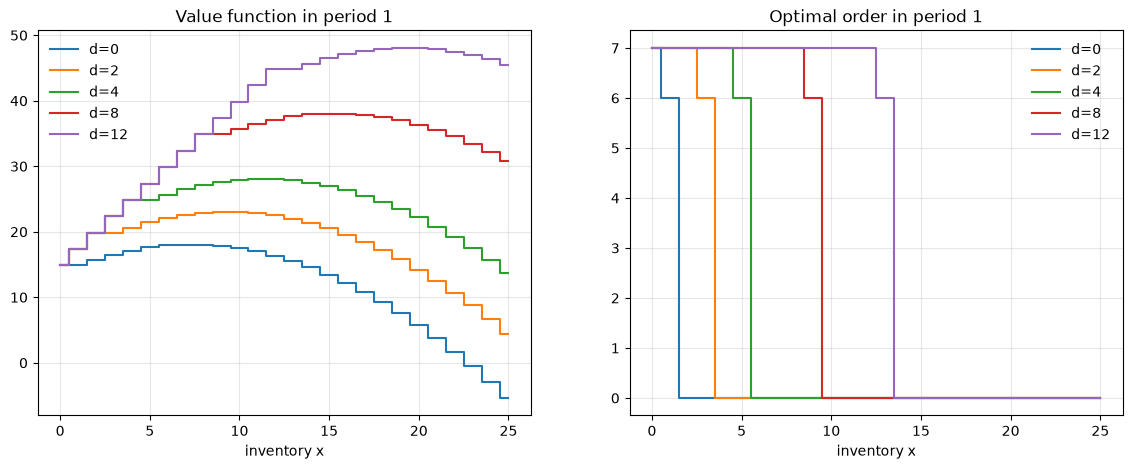

Optimal order in period 1, demand in rows, inventory in columns:
[[7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0 0]
 [7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 6 0 0 0 0 0 0 0 0]


In [5]:
mod = inventory_model_stochastic(label='stochastic demand', max_inventory=25, λ=0.25)
mod = solver_backwards_induction(mod, T=15)

def plot_solution_xd(m, t=1, demands=(0,2,4,8,12)):
    '''Value and policy of period t against inventory, one line per level of demand'''
    j = t-1
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
    for d in demands:
        ax1.step(m.x, m.value[d,:,j],  where='mid', label=f'd={d}')
        ax2.step(m.x, m.policy[d,:,j], where='mid', label=f'd={d}')
    ax1.set_title(f'Value function in period {t}')
    ax2.set_title(f'Optimal order in period {t}')
    for ax in (ax1,ax2):
        ax.set_xlabel('inventory x'); ax.legend(frameon=False); ax.grid(alpha=.3)
    plt.show()

plot_solution_xd(mod)

np.set_printoptions(linewidth=160)
print('Optimal order in period 1, demand in rows, inventory in columns:')
print(mod.policy[:,:,0])

What structure do you see in that matrix? What does it say about the information
the manager actually needs in order to place an order — is it $x$ and $d$ separately?

The matrix is constant along its diagonals: moving one step down and one step right,
from $(d,x)$ to $(d+1,x+1)$, never changes the order. The whole lower-left triangle,
where $x \le d$, is one constant, and each diagonal to the right of the main one is
another. Every row is the previous row shifted right by one cell.

So the order is a function of $x-d$ when this is positive, and of nothing when it is
not: it depends on the state only through the post-sale stock $y = \max\{x-d,0\}$.
This is visible in the Bellman equation. Demand enters the profit through the sales
$p\min\{x,d\}$, which do not depend on $q$ and drop out of the argmax, and everything
that involves $q$ — the storage cost, the fixed cost, the continuation value — involves
$x$ and $d$ only through $y$. Next period demand is independent of today's, so the
expectation does not bring $d$ back either.

The manager does not need $x$ and $d$ separately, only what is left on the shelf after
the customers have gone. The *value* $V_t(x,d)$ does depend on both, through the sales
already made, but the *decision* is one-dimensional. Read along a diagonal it is an
$(s,S)$ rule: order nothing when $y$ is above the threshold $s=1$, and order up to the
target $S=7$ otherwise, $7$ units at $y=0$ and $6$ at $y=1$.

## 5. Code up a simulator for the model

Given a solved model, the simulator for the model should start at a given inventory level at time $t_0$, and then iterate on taking random draws of demand, computing the optimal order, and updating the inventory for the next period. The simulator should run for a given number of periods, and return the realized inventory levels, orders, and profits over time.
As requested, the simulator should also make illustrative plots of the inventory levels, orders, and profits over time.

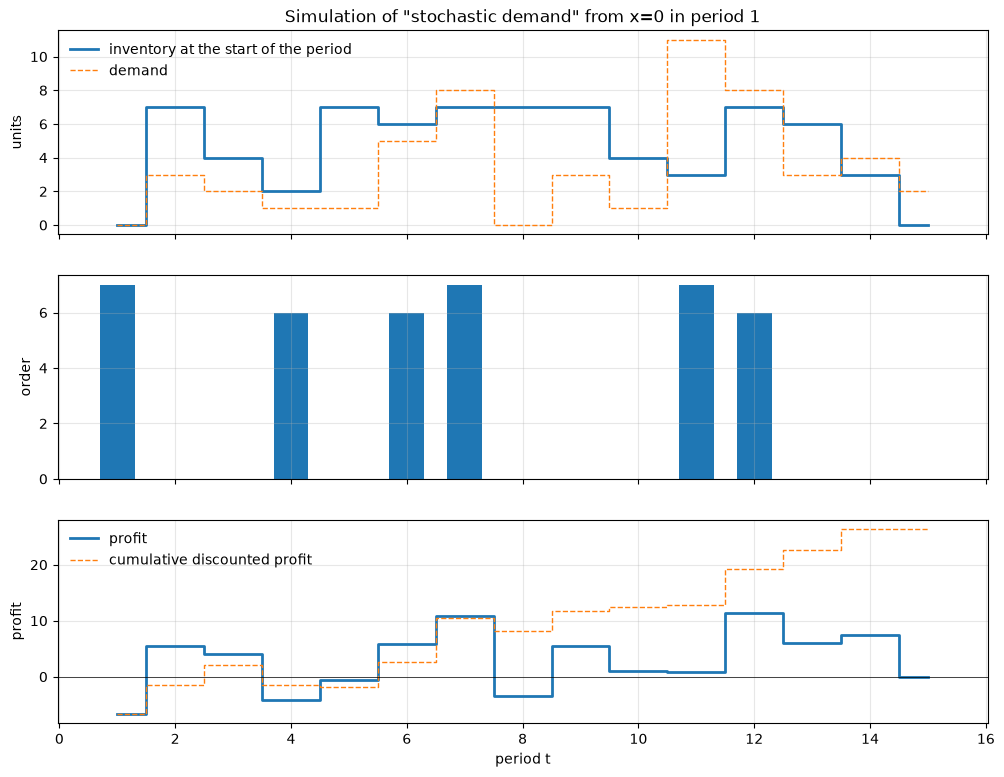

In [6]:
def simulator(m, x0=0, t0=1, periods=None, seed=None, plot=True):
    '''Simulate the solved finite horizon model from inventory x0 in period t0.
    Runs for the given number of periods, or until the last period T of the solution.
    Returns a dict with periods, demand, inventory (one longer, the stock carried into
    the period after the last), orders and profits.
    '''
    T = m.policy.shape[2]
    if periods is None or periods > T-t0+1:
        periods = T-t0+1                       # policy is not defined beyond T
    rng = np.random.default_rng(seed)
    d = rng.choice(m.x, size=periods, p=m.demand_pr())   # i.i.d. draws of demand
    x = np.zeros(periods+1, dtype=int); x[0] = x0
    q = np.zeros(periods, dtype=int)
    profit = np.zeros(periods)
    for k in range(periods):
        t = t0 + k
        q[k] = m.policy[d[k], x[k], t-1]                     # optimal order at (d,x) in period t
        profit[k] = m.profit(x[k], d[k], q[k])
        # the cap never binds: the solver values an order that overshoots the grid as if it
        # landed on the last point and charges full storage for it, so it is never optimal
        x[k+1] = min(m.next_x(x[k], d[k], q[k]), m.upper)
    sim = dict(t=np.arange(t0, t0+periods), d=d, x=x[:-1], x_next=x[-1], q=q, profit=profit)
    if plot:
        plot_simulation(sim, m)
    return sim

def plot_simulation(sim, m):
    '''Inventory and demand, orders, and profit over time'''
    fig, axes = plt.subplots(3,1,figsize=(12,9),sharex=True)
    t = sim['t']
    axes[0].step(t, sim['x'], where='mid', lw=2, label='inventory at the start of the period')
    axes[0].step(t, sim['d'], where='mid', lw=1, ls='--', label='demand')
    axes[0].set_ylabel('units'); axes[0].legend(frameon=False)
    axes[1].bar(t, sim['q'], width=0.6)
    axes[1].set_ylabel('order')
    axes[2].step(t, sim['profit'], where='mid', lw=2, label='profit')
    axes[2].step(t, np.cumsum(sim['profit'] * m.β**(t-t[0])), where='mid', lw=1, ls='--',
                 label='cumulative discounted profit')
    axes[2].axhline(0, color='k', lw=.5)
    axes[2].set_ylabel('profit'); axes[2].set_xlabel('period t'); axes[2].legend(frameon=False)
    for ax in axes: ax.grid(alpha=.3)
    axes[0].set_title(f'Simulation of "{m.label}" from x={sim["x"][0]} in period {t[0]}')
    plt.show()

sim = simulator(mod, x0=0, t0=1, seed=2026)

## 6. Play with the model

Vary $\lambda$, the fixed order cost $c$, the storage cost $r$ and the discount factor
$\beta$, and compare the solutions. Which parameter changes the *shape* of the policy,
and which only shifts it? How does the policy in the last few periods differ from the
policy early on, and why? How do simulations from the two solutions differ?

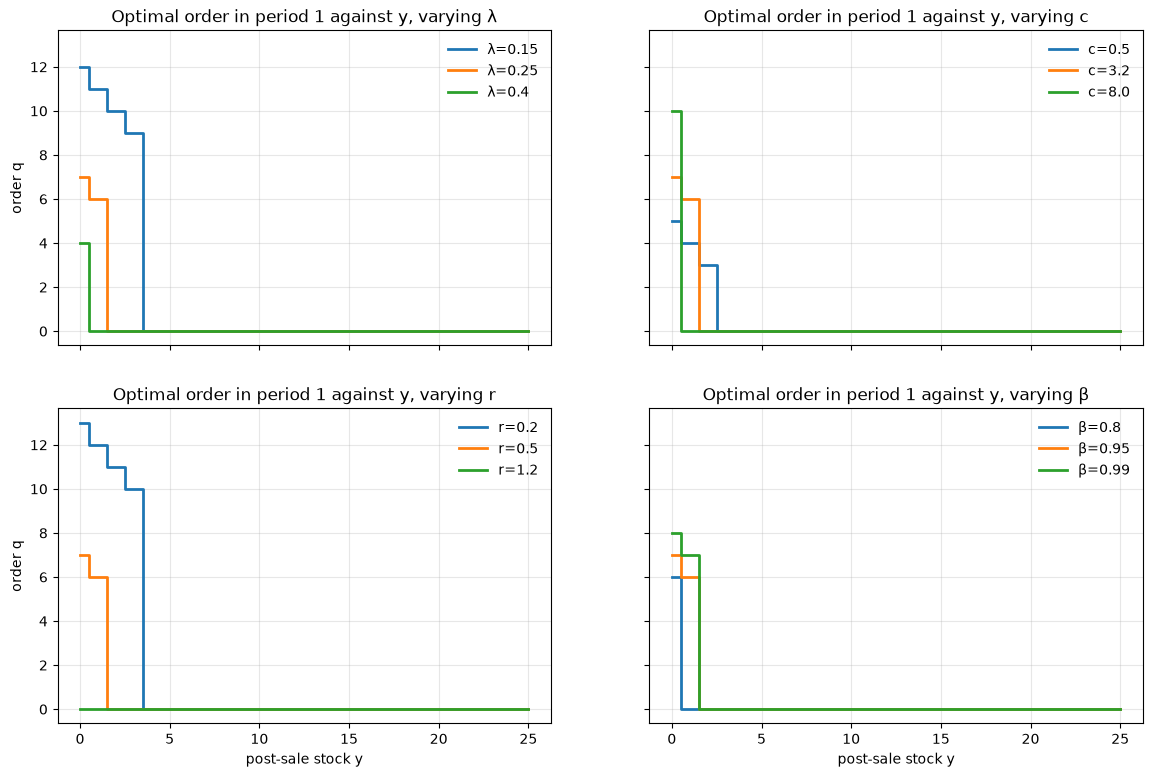

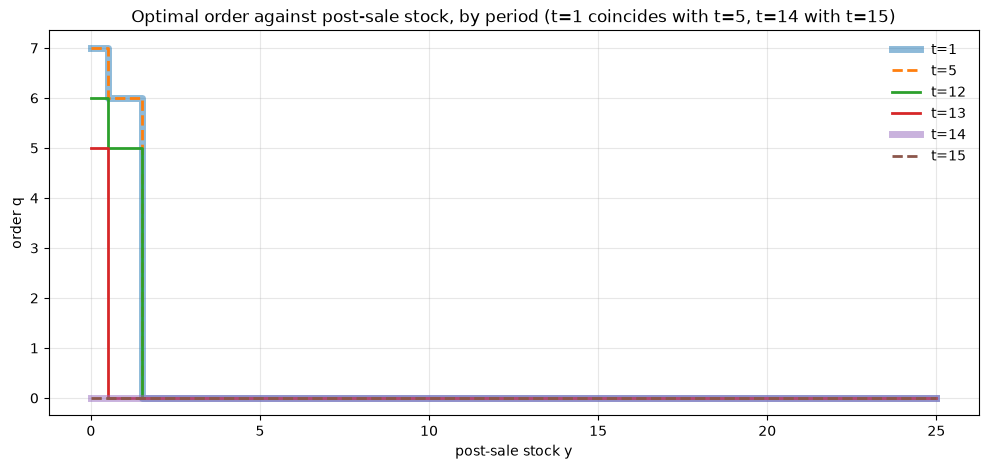

The policy differs from the next period's in periods [11, 12, 13]


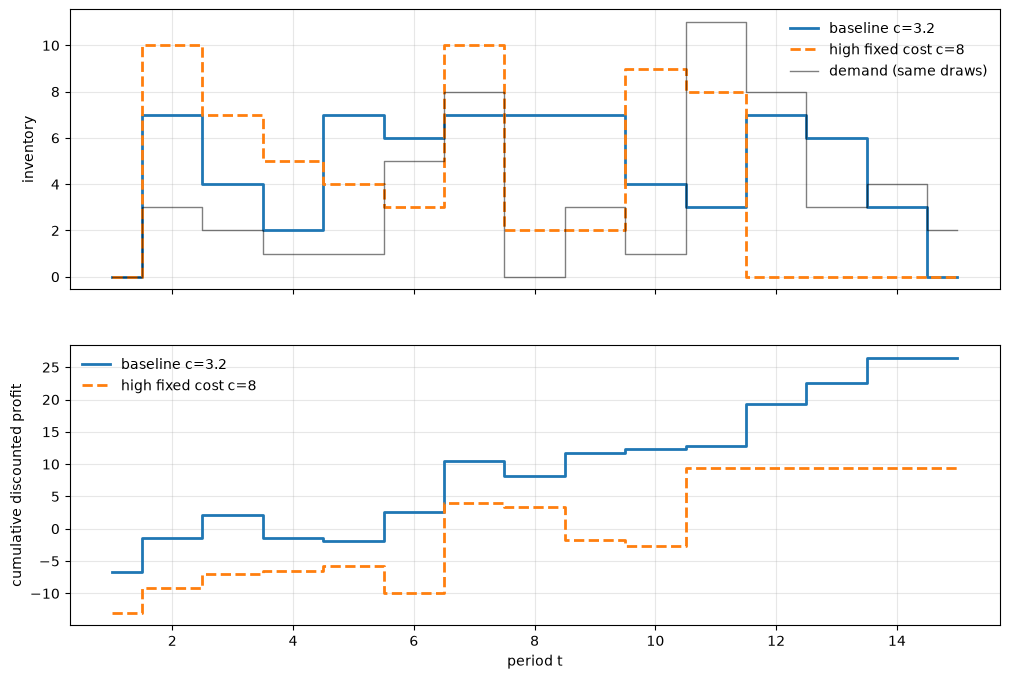

baseline c=3.2         expected discounted profit from x=0:  14.8546
high fixed cost c=8    expected discounted profit from x=0:   1.0693


In [7]:
# the order depends on the state only through y = max(x-d,0), so it is enough to compare
# policies along the row d=0, where y = x: first period policy of T=15 solutions, baseline
# in the middle of each triple
base = dict(max_inventory=25, λ=0.25, c=3.2, p=2.5, r=0.5, β=0.95)
variations = {'λ': (0.15, 0.25, 0.40),
              'c': (0.5, 3.2, 8.0),
              'r': (0.2, 0.5, 1.2),
              'β': (0.80, 0.95, 0.99)}

def solve_with(T=15, **changes):
    kw = dict(base); kw.update(changes)
    return solver_backwards_induction(inventory_model_stochastic(**kw), T=T)

fig, axes = plt.subplots(2,2,figsize=(14,9),sharex=True,sharey=True)
for ax,(par,vals) in zip(axes.flat, variations.items()):
    for v in vals:
        m = solve_with(**{par:v})
        ax.step(m.x, m.policy[0,:,0], where='mid', lw=2, label=f'{par}={v}')
    ax.set_title(f'Optimal order in period 1 against y, varying {par}')
    ax.legend(frameon=False); ax.grid(alpha=.3)
for ax in axes[1]: ax.set_xlabel('post-sale stock y')
for ax in axes[:,0]: ax.set_ylabel('order q')
plt.show()

# the policy over time: first period against the last few periods
fig, ax = plt.subplots(figsize=(12,5))
for t,lw,ls in ((1,5,'-'), (5,2,'--'), (12,2,'-'), (13,2,'-'), (14,5,'-'), (15,2,'--')):
    ax.step(mod.x, mod.policy[0,:,t-1], where='mid', lw=lw, ls=ls, alpha=.5 if lw>2 else 1, label=f't={t}')
ax.set_title('Optimal order against post-sale stock, by period (t=1 coincides with t=5, t=14 with t=15)')
ax.set_xlabel('post-sale stock y'); ax.set_ylabel('order q')
ax.legend(frameon=False); ax.grid(alpha=.3)
plt.show()

T = mod.policy.shape[2]
changed = [t for t in range(1,T) if np.any(mod.policy[:,:,t-1] != mod.policy[:,:,t])]
print('The policy differs from the next period\'s in periods', changed)

# simulations from two solutions with the same demand draws
alt = solve_with(c=8.0); alt.label = 'high fixed cost c=8'
mod.label = 'baseline c=3.2'
fig, axes = plt.subplots(2,1,figsize=(12,8),sharex=True)
for m,ls in ((mod,'-'),(alt,'--')):
    sim = simulator(m, x0=0, t0=1, seed=2026, plot=False)
    axes[0].step(sim['t'], sim['x'], where='mid', lw=2, ls=ls, label=m.label)
    axes[1].step(sim['t'], np.cumsum(sim['profit']*m.β**(sim['t']-1)), where='mid', lw=2, ls=ls, label=m.label)
axes[0].step(sim['t'], sim['d'], where='mid', lw=1, color='k', alpha=.5, label='demand (same draws)')
axes[0].set_ylabel('inventory'); axes[0].legend(frameon=False)
axes[1].set_ylabel('cumulative discounted profit'); axes[1].set_xlabel('period t'); axes[1].legend(frameon=False)
for ax in axes: ax.grid(alpha=.3)
plt.show()
for m in (mod,alt):
    print(f'{m.label:22s} expected discounted profit from x=0: {m.demand_pr() @ m.value[:,0,0]:8.4f}')

**Shape against shift.** Every policy in the first figure is an $(s,S)$ rule, but only
the fixed cost $c$ changes what the rule looks like. At $c=0.5$ the manager orders
whenever the stock falls to $2$ or below and tops it up to $5$: small frequent orders,
close to the order-up-to rule that is optimal at $c=0$. At $c=8$ orders are placed only
on an empty shelf and are large, $10$ units, because a fixed cost paid once should buy
as many selling periods as possible. The width of the inaction region $S-s$ is the
fixed cost at work.

The other three parameters shift the thresholds without changing the picture. Higher
demand (lower $\lambda$) and cheaper storage (lower $r$) move both $s$ and $S$ up, with
$S=12$ at $\lambda=0.15$ and $S=13$ at $r=0.2$, while at $\lambda=0.4$ or $r=1.2$ the
manager holds almost nothing. The discount factor hardly matters in this range: a stock
of $7$ sells in two or three periods, and discounting over that span is small whether
$\beta$ is $0.8$ or $0.99$.

**Early against late.** The period 1 policy is identical to the period 5 one. Backwards
induction from the terminal condition settles down after four steps, and periods $1$ to
$11$ share the same policy, which is the infinite horizon solution of the next class.
The end of the horizon shows only in the last four periods. The target falls to $6$ in
period $12$ and to $5$ in period $13$, because a stock bought late has fewer periods to
sell in, and in periods $14$ and $15$ nothing is ordered at all: one period of sales
does not recover the fixed cost, as already seen in the small model of section 3.

**Simulations.** With the same demand draws, the high fixed cost manager orders three
times instead of four, carries a larger stock after each order, and runs the shelf
empty for the last four periods, losing sales. The baseline earns more on this path,
$26$ against $9$, and in expectation, $14.9$ against $1.1$ from an empty shelf. One path
is a noisy comparison: the realized profit of the baseline here is well above its
expectation, and the right comparison is the expected value function itself, or an
average over many simulated paths.